# 01. Adult Census 데이터 로딩 및 품질 비교

## Goal

동일한 UCI Adult 원본을 Pandas와 Polars로 읽고 shape, 컬럼, 결측치, 고유값, 중복 행이 일치하는지 확인합니다.

## Setup

이 노트북은 프로젝트의 `src/data.py`를 호출합니다. 원본 파일이 없을 때만 UCI URL에서 다운로드합니다.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise RuntimeError('adult-marriage-analysis 프로젝트 루트에서 실행하세요.')

sys.path.insert(0, str(project_root))

from src.data import (
    compare_frames,
    ensure_raw_data,
    load_with_pandas,
    load_with_polars,
)
from src.eda import build_missingness_summary, build_validity_summary
from src.visualization import create_missingness_chart

project_root

PosixPath('/Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-analysis')

## Steps

### 1. 동일한 원본 데이터 불러오기

In [2]:
raw_path = ensure_raw_data(project_root / 'data' / 'raw')
pandas_df = load_with_pandas(raw_path)
polars_df = load_with_polars(raw_path)

print('원본 경로:', raw_path)
print('Pandas shape:', pandas_df.shape)
print('Polars shape:', polars_df.shape)

원본 경로: /Users/beeyaaa/Workspace/SK-SKALA/day15_data/adult-marriage-analysis/data/raw/adult.data
Pandas shape: (32561, 15)
Polars shape: (32561, 15)


### 2. 데이터 일부 확인

In [3]:
pandas_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
polars_df.head()

age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
39,"""State-gov""",77516,"""Bachelors""",13,"""Never-married""","""Adm-clerical""","""Not-in-family""","""White""","""Male""",2174,0,40,"""United-States""","""<=50K"""
50,"""Self-emp-not-inc""",83311,"""Bachelors""",13,"""Married-civ-spouse""","""Exec-managerial""","""Husband""","""White""","""Male""",0,0,13,"""United-States""","""<=50K"""
38,"""Private""",215646,"""HS-grad""",9,"""Divorced""","""Handlers-cleaners""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States""","""<=50K"""
53,"""Private""",234721,"""11th""",7,"""Married-civ-spouse""","""Handlers-cleaners""","""Husband""","""Black""","""Male""",0,0,40,"""United-States""","""<=50K"""
28,"""Private""",338409,"""Bachelors""",13,"""Married-civ-spouse""","""Prof-specialty""","""Wife""","""Black""","""Female""",0,0,40,"""Cuba""","""<=50K"""


### 3. 전체 및 컬럼별 비교

In [5]:
comparison_summary, column_comparison = compare_frames(
    pandas_df, polars_df
)
comparison_summary

,pandas_rows,polars_rows,pandas_columns,polars_columns,column_order_equal,total_nulls_equal,pandas_duplicate_rows,polars_duplicate_rows
0,32561,32561,15,15,True,True,24,24


In [6]:
column_comparison

,column,pandas_dtype,polars_dtype,pandas_nulls,polars_nulls,null_count_equal,pandas_unique,polars_unique,unique_count_equal
0,age,int64,Int64,0,0,True,73,73,True
1,workclass,object,String,1836,1836,True,8,8,True
2,fnlwgt,int64,Int64,0,0,True,21648,21648,True
3,education,object,String,0,0,True,16,16,True
4,education-num,int64,Int64,0,0,True,16,16,True
5,marital-status,object,String,0,0,True,7,7,True
6,occupation,object,String,1843,1843,True,14,14,True
7,relationship,object,String,0,0,True,6,6,True
8,race,object,String,0,0,True,5,5,True
9,sex,object,String,0,0,True,2,2,True


### 4. Question-driven EDA — 결측치는 어디에, 얼마나 존재하는가?

결측치 개수·비율을 표와 막대그래프로 확인한 뒤 처리 방향을 기록합니다.

In [7]:
missingness = build_missingness_summary(pandas_df)
print('[Question] 결측치는 어디에, 얼마나 존재하는가?')
print(missingness.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print('\n[Next Action] workclass·occupation은 모델 Pipeline 안에서 Unknown으로 대치합니다.')
print('[Next Action] native-country는 기본 모델 입력에서 제외하고 데이터 품질 기록만 남깁니다.')
missingness

[Question] 결측치는 어디에, 얼마나 존재하는가?
        column  missing_count  missing_rate_pct
    occupation           1843              5.66
     workclass           1836              5.64
native-country            583              1.79

[Next Action] workclass·occupation은 모델 Pipeline 안에서 Unknown으로 대치합니다.
[Next Action] native-country는 기본 모델 입력에서 제외하고 데이터 품질 기록만 남깁니다.


,column,missing_count,missing_rate_pct
0,occupation,1843,5.660146
1,workclass,1836,5.638647
2,native-country,583,1.790486


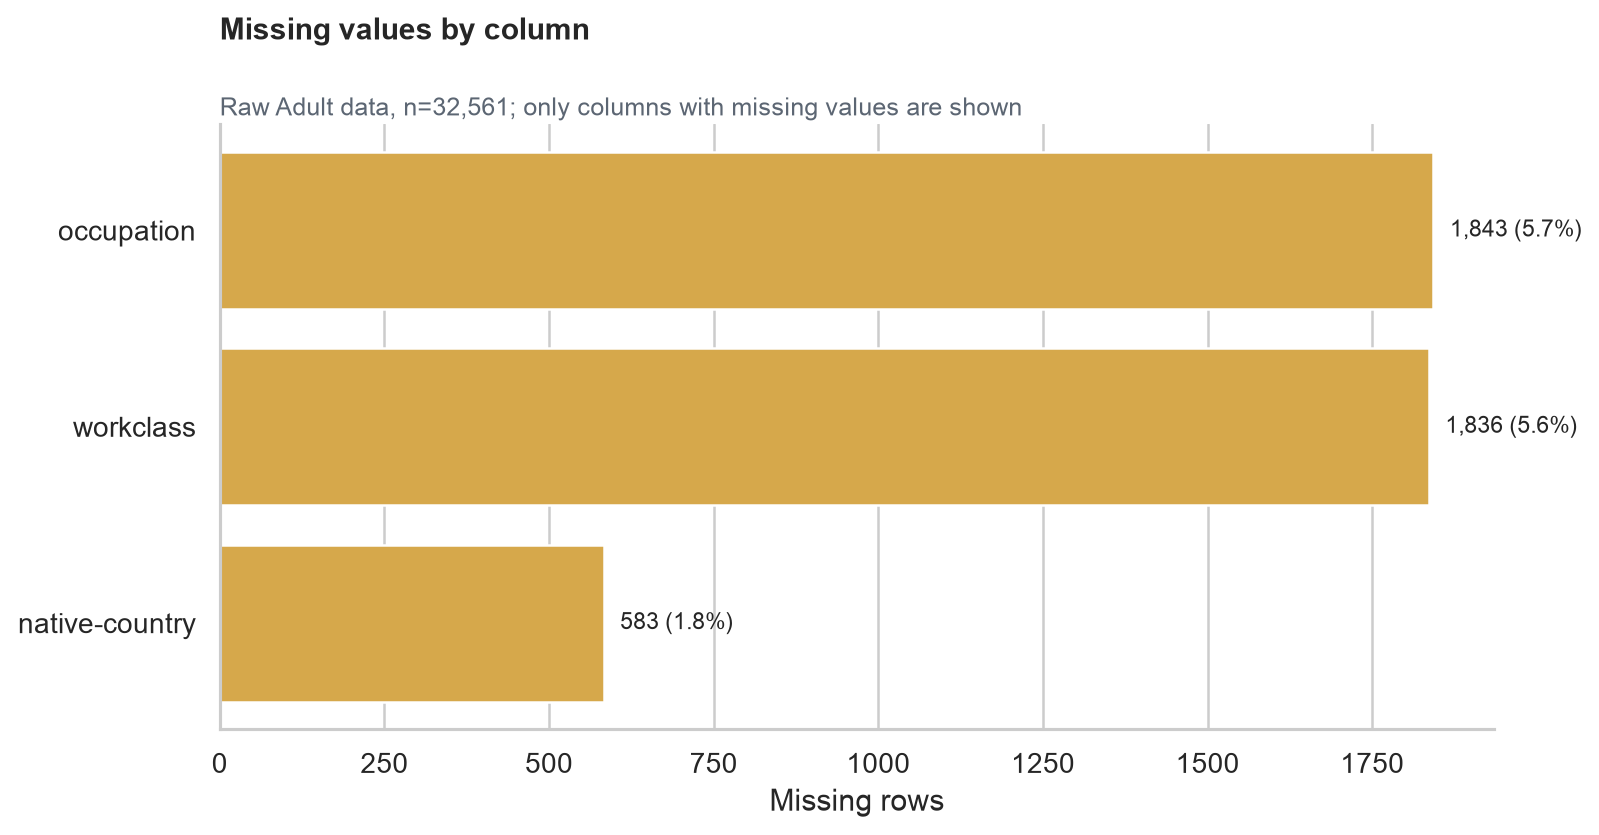

In [8]:
missing_chart_path = create_missingness_chart(
    pandas_df,
    project_root / 'reports' / 'figures' / 'eda_missing_values.png',
)
display(Image(filename=str(missing_chart_path)))

### 5. 중복이나 논리적으로 유효하지 않은 값은 없는가?

중복은 개인 식별자가 없는 Census 표본이라는 점을 고려하고, 주요 숫자형 범위도 함께 점검합니다.

In [9]:
duplicate_rows = int(pandas_df.duplicated().sum())
validity_summary = build_validity_summary(pandas_df)
print(f'[Question] 완전 중복 행: {duplicate_rows:,}개')
print('[Next Action] 개인 식별자가 없어 서로 다른 응답자일 수 있으므로 자동 삭제하지 않습니다.')
print('\n[Question] 숫자형 논리 범위 점검')
display(validity_summary)
print('[Next Action] 범위 위반이 없으므로 오류값 대치 없이 다음 EDA로 진행합니다.')

[Question] 완전 중복 행: 24개
[Next Action] 개인 식별자가 없어 서로 다른 응답자일 수 있으므로 자동 삭제하지 않습니다.

[Question] 숫자형 논리 범위 점검


,column,rule,invalid_count,status
0,age,17 <= age <= 90,0,PASS
1,education-num,1 <= education-num <= 16,0,PASS
2,hours-per-week,1 <= hours-per-week <= 99,0,PASS
3,capital-gain,capital-gain >= 0,0,PASS
4,capital-loss,capital-loss >= 0,0,PASS


[Next Action] 범위 위반이 없으므로 오류값 대치 없이 다음 EDA로 진행합니다.


### 6. Question → Analysis → Next Action 요약

In [10]:
quality_decisions = pd.DataFrame([
    {
        'Question': '결측치는 어디에, 얼마나 존재하는가?',
        'Analysis': '컬럼별 isna().sum(), 결측 비율, 막대그래프',
        'Observed': ', '.join(f"{r.column} {int(r.missing_count):,}건" for r in missingness.itertuples()),
        'Next Action': '범주형 입력은 Pipeline 내부에서 Unknown 대치',
    },
    {
        'Question': '중복이나 유효하지 않은 값은 없는가?',
        'Analysis': 'duplicated(), 논리 범위 규칙',
        'Observed': f'완전 중복 {duplicate_rows:,}건, 범위 위반 {validity_summary.invalid_count.sum():,}건',
        'Next Action': '중복은 자동 삭제하지 않고 범위 위반 없음 확인',
    },
])
quality_decisions

,Question,Analysis,Observed,Next Action
0,"결측치는 어디에, 얼마나 존재하는가?","컬럼별 isna().sum(), 결측 비율, 막대그래프","occupation 1,843건, workclass 1,836건, native-co...",범주형 입력은 Pipeline 내부에서 Unknown 대치
1,중복이나 유효하지 않은 값은 없는가?,"duplicated(), 논리 범위 규칙","완전 중복 24건, 범위 위반 0건",중복은 자동 삭제하지 않고 범위 위반 없음 확인


## Checks

두 라이브러리의 핵심 결과가 모두 일치하는지 자동 확인합니다.

In [11]:
assert comparison_summary.loc[0, 'pandas_rows'] == 32_561
assert comparison_summary.loc[0, 'pandas_rows'] == comparison_summary.loc[0, 'polars_rows']
assert comparison_summary.loc[0, 'column_order_equal']
assert comparison_summary.loc[0, 'total_nulls_equal']
assert comparison_summary.loc[0, 'pandas_duplicate_rows'] == comparison_summary.loc[0, 'polars_duplicate_rows']
assert column_comparison['null_count_equal'].all()
assert column_comparison['unique_count_equal'].all()

assert missing_chart_path.exists() and missing_chart_path.stat().st_size > 0
assert validity_summary['invalid_count'].eq(0).all()
print('검증 완료: Pandas와 Polars의 로딩 결과가 일치합니다.')

검증 완료: Pandas와 Polars의 로딩 결과가 일치합니다.


## Next Steps

- 확인된 데이터 크기: **32,561행 × 15열**
- 결측치가 있는 컬럼: `workclass`, `occupation`, `native-country`
- 완전 중복 행: **24개** — 개인 식별자가 없어 자동 삭제하지 않음
- 다음 단계: `ever_married` 타깃 생성과 누수 변수 제거